# 01. Öğrenci Başarı Notu Tahmini

**Kategori:** Regresyon  
**Gerçek veri seti:** UCI Student Performance  
**Veri kaynağı:** [https://archive.ics.uci.edu/dataset/320/student+performance](https://archive.ics.uci.edu/dataset/320/student+performance)  
**Amaç:** Öğrencinin demografik, okul ve önceki not bilgileriyle final notunu (G3) tahmin etmek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Veriyi yükleme ve kalite kontrolü

In [2]:
df = pd.read_csv(DATA_DIR / "student_performance.csv")
display(df.head())
print(f"Boyut: {df.shape[0]} satır × {df.shape[1]} sütun")
display(pd.DataFrame({"tip": df.dtypes, "eksik": df.isna().sum(), "benzersiz": df.nunique()}))
print("Tekrarlı satır:", df.duplicated().sum())

Boyut: 395 satır × 33 sütun
Tekrarlı satır: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


,tip,eksik,benzersiz
school,object,0,2
sex,object,0,2
age,int64,0,8
address,object,0,2
famsize,object,0,2
Pstatus,object,0,2
Medu,int64,0,5
Fedu,int64,0,5
Mjob,object,0,5
Fjob,object,0,5


## 2. EDA ve görselleştirme

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,395,2,GP,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,395,2,F,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,395.0,NaN,NaN,NaN,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
address,395,2,U,307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,395,2,GT3,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,395,2,T,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,395.0,NaN,NaN,NaN,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,NaN,NaN,NaN,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
Mjob,395,5,other,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,395,5,other,217,NaN,NaN,NaN,NaN,NaN,NaN,NaN


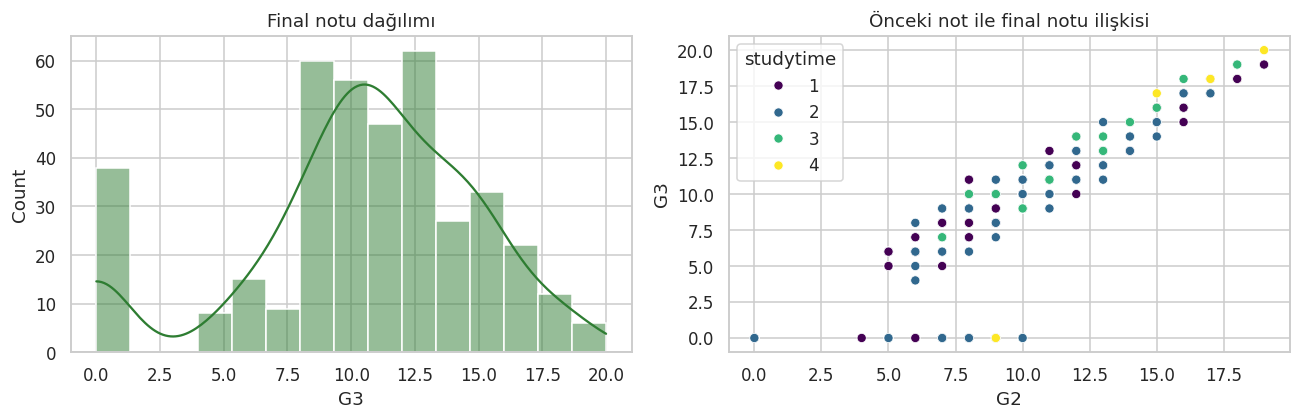

In [3]:
display(df.describe(include="all").T.head(15))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["G3"], bins=15, kde=True, ax=axes[0], color="#2E7D32")
axes[0].set(title="Final notu dağılımı", xlabel="G3")
sns.scatterplot(data=df, x="G2", y="G3", hue="studytime", palette="viridis", ax=axes[1])
axes[1].set(title="Önceki not ile final notu ilişkisi")
plt.tight_layout(); plt.show()

## 3. Ön işleme, model karşılaştırması ve değerlendirme

In [4]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X, y = df.drop(columns="G3"), df["G3"]
num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns
preprocess = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num_cols),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore")), cat_cols),
])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
candidates = {
    "Doğrusal Regresyon": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=250, min_samples_leaf=2,
                                            random_state=RANDOM_STATE, n_jobs=-1),
}
fitted = {name: make_pipeline(clone(preprocess), model).fit(X_train, y_train)
          for name, model in candidates.items()}
predictions = {name: model.predict(X_test) for name, model in fitted.items()}
scores = pd.DataFrame({name: {
    "MAE": mean_absolute_error(y_test, pred),
    "RMSE": root_mean_squared_error(y_test, pred),
    "R2": r2_score(y_test, pred),
} for name, pred in predictions.items()}).T.sort_values("MAE")
display(scores.round(3))

,MAE,RMSE,R2
Random Forest,1.221,2.043,0.796
Doğrusal Regresyon,1.647,2.378,0.724


Kaydedilen model: Random Forest


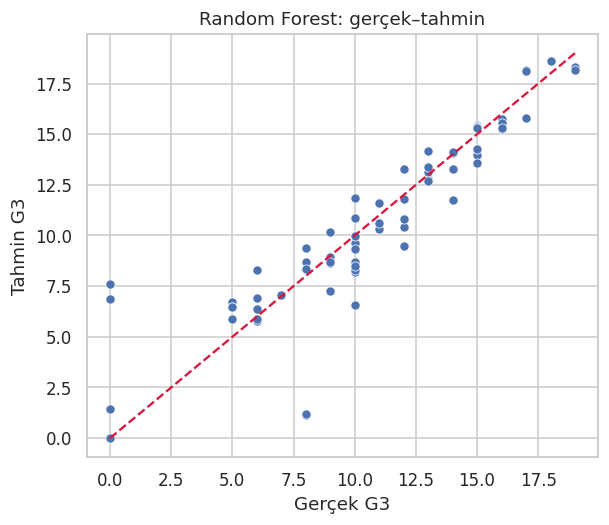

In [5]:
best_name = scores.index[0]
best_model = fitted[best_name]
best_pred = predictions[best_name]
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=best_pred)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, "--", color="crimson")
plt.xlabel("Gerçek G3"); plt.ylabel("Tahmin G3"); plt.title(f"{best_name}: gerçek–tahmin")
plt.show()

artifact = {"best_name": best_name, "best_model": best_model,
            "all_models": fitted, "metrics": scores.to_dict()}
joblib.dump(artifact, MODEL_DIR / "01_ogrenci_basari.joblib")
json.dump({"best_model": best_name, **scores.loc[best_name].to_dict()},
          open(RESULT_DIR / "01_ogrenci_basari.json", "w"), indent=2)
print("Kaydedilen model:", best_name)

## Sonuç

En düşük MAE değerine sahip model seçildi. `G2` finalden hemen önceki not olduğu için güçlü bir
tahmin değişkenidir; bu bir veri sızıntısı değildir ancak kullanım senaryosunda tahmin zamanının
G2 açıklandıktan sonra olması gerekir. Daha erken uyarı sistemi için G1 ve G2 çıkarılarak ayrı bir
model kurulmalıdır.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **tek bir regresyon modelinin hızlıca kurulması** biçimindedir.
Bu notebookta **gerçek okul verisi, karma veri tipleri için ColumnTransformer, iki model ve üç regresyon metriği** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).